# Lecture 3: Probing and Steering

In this lecture, we will introduce the basics of **probing** and **steering** -- ways to **decode** their activations of neural networks and manipulate them to **control** their behavior.

### ✍ Learning goals

By the end of the lesson, we hope you feel familiar with the following concepts.

* **Linear probing**: decoding neural activations with linear transformations
* **Differennce-in-means steering**: simple but effective method for controlling model behavior through its activations

## 0️⃣ Setup

In [1]:
from IPython.display import clear_output
import plotly.io as pio

try:
    import google.colab
    is_colab = True
except ImportError:
    is_colab = False

if is_colab:
    pio.renderers.default = "colab"
else:
    pio.renderers.default = "plotly_mimetype+png"
    !uv sync
    !plotly_get_chrome -y

clear_output()

For this lecture, we'll focus on a ~2B base model created by 🤗 Transformers.

In [2]:
from nnsight import LanguageModel

model = LanguageModel("HuggingFaceTB/SmolLM2-1.7B")

clear_output()

## 1️⃣ Understanding internals by probing activations

### Logit lens

In [3]:
with model.generate("Espanol: amor, Francais:"):
  output = model.generator.output.save()

clear_output() # ignore comments for model loading

print(model.tokenizer.decode(output))

['Espanol: amor, Francais: amour, Deutsch: Liebe, Italiano: amore, Portugues: amor,']


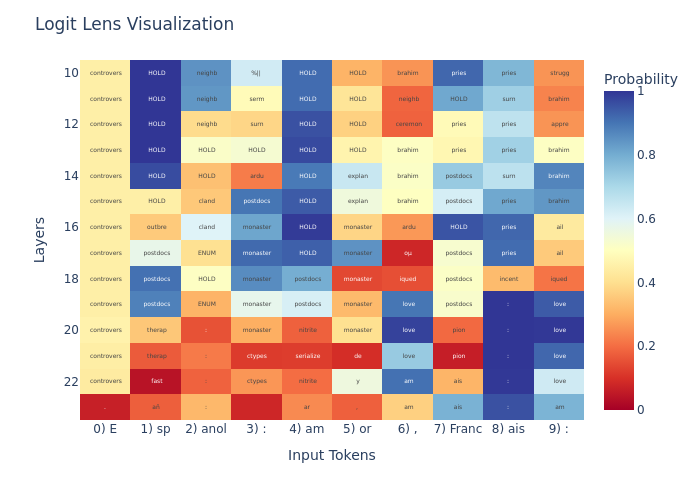

In [4]:
import torch
import plotly.express as px

prompt= "Espanol: amor, Francais:"

layer_range = list(range(10, len(model.model.layers)))

decoded_layers = []
with model.trace(prompt):
    for layer_index in layer_range:
        # get layer activation
        layer_activation = model.model.layers[layer_index].output
        layer_activation = model.model.norm(layer_activation)
        # pass the layer through the final LM head to predict next token
        decoded_layer_logits = model.lm_head(layer_activation)
        # apply softmax to get a probability distribution over the next token
        decoded_layer = torch.nn.functional.softmax(decoded_layer_logits, dim=-1)
        decoded_layers.append(decoded_layer.save())

decoded_layers = torch.cat(decoded_layers) # (num_layers, num_tokens, vocab_size)

# find the maximum probability and corresponding tokens for each position
probabilities, decoded_tokens = decoded_layers.max(dim=-1)

# decode token ids
decoded_tokens = [
    [model.tokenizer.decode(t.item()) for t in layer_tokens]
    for layer_tokens in decoded_tokens
]

input_tokens = [t.replace('Ġ', '') for t in model.tokenizer.tokenize(prompt)]

fig = px.imshow(
    probabilities.detach().cpu().float().numpy(),
    x=[f"{i}) {t}" for i, t in enumerate(input_tokens)],
    y=layer_range,
    color_continuous_scale=px.colors.diverging.RdYlBu,
    color_continuous_midpoint=0.50,
    text_auto=True,
    labels=dict(x="Input Tokens", y="Layers", color="Probability")
)

fig.update_layout(
    title='Logit Lens Visualization',
    xaxis_tickangle=0
)

fig.update_traces(text=decoded_tokens, texttemplate="%{text}")
fig.show()

### ✏ **Exercise 1**

**TODO**

*Hint: TODO*

> FILL IN YOUR ANSWER HERE

### Visualizing activations


In [5]:
ENGLISH_TO_FRENCH = [
    "English: dog, Francais:",
    "English: cat, Francais:",
    "English: mouse, Francais:",
    "English: fish, Francais:",
    "English: bird, Francais:",
    "English: turtle, Francais:",
    "English: monkey, Francais:",
    "English: bear, Francais:",
    "English: lion, Francais:",
    "English: penguin, Francais:"
]

ENGLISH_TO_SPANISH = [
    "English: dog, Espanol:",
    "English: cat, Espanol:",
    "English: mouse, Espanol:",
    "English: fish, Espanol:",
    "English: bird, Espanol:",
    "English: turtle, Espanol:",
    "English: monkey, Espanol:",
    "English: bear, Espanol:",
    "English: lion, Espanol:",
    "English: penguin, Espanol:"
]

In [6]:
# let's collect the model's activations over each statement at the same location
from tqdm import tqdm
import torch

LAYER = 10 # pick a middle layer

with torch.no_grad():
  french_activations = []
  for french_prompt in tqdm(ENGLISH_TO_FRENCH, desc="French"):
    with model.trace(french_prompt):
      # get activation at layer L & last token (:)
      french_activations.append(
          model.model.layers[LAYER].output[:, -1, :].save()
      )

  # repeat for english-to-spanish prompts
  spanish_activations = []
  for spanish_prompt in tqdm(ENGLISH_TO_SPANISH, desc="Spanish"):
    with model.trace(spanish_prompt):
      spanish_activations.append(
          model.model.layers[LAYER].output[:, -1, :].save()
      )

# convert to tensors
french_activations = torch.cat(french_activations) # (10, hidden_dim)
spanish_activations = torch.cat(spanish_activations) # (10, hidden_dim)

Spanish: 100%|██████████| 10/10 [00:09<00:00,  1.09it/s]


In [7]:
# go from hidden size -> 2 dimensions with PCA!
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
all_activations = torch.cat([french_activations, spanish_activations]).cpu().float().numpy() # (20, hidden_dim)

low_dim_activations = pca.fit_transform(all_activations) # (20, 2)
low_dim_activations.shape

(20, 2)

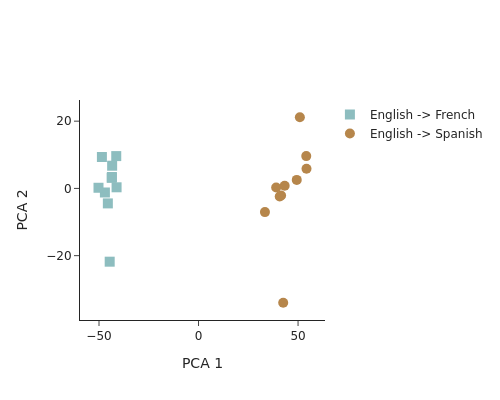

In [9]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
  x=low_dim_activations[:10, 0],
  y=low_dim_activations[:10, 1],
  mode='markers',
  marker=dict(symbol='square', color="#8dbdbf", size=10),
  name='English -> French',
  hovertext=ENGLISH_TO_FRENCH,
))

fig.add_trace(go.Scatter(
  x=low_dim_activations[10:, 0],
  y=low_dim_activations[10:, 1],
  mode='markers',
  marker=dict(symbol='circle', color="#b6864b", size=10),
  name='English -> Spanish',
  hovertext=ENGLISH_TO_SPANISH,
))

fig.update_layout(
  template='simple_white',
  width=500,
  height=400,
  xaxis_title='PCA 1',
  yaxis_title='PCA 2',
)

fig.show()

### ✏ **Exercise 2**

The PCA dimensions we identified are constrained to the dataset of animals we procured.

For instance, PCA 1 seems to clearly separate between English-to-French translation prompts and English-to-Spanish translation prompts. Anything below 0 on the PCA 1 axis is English-to-French, and anything about 0 is English-to-Spanish.

But what if we go beyond animals? Does our analysis hold for other translations?

Come up with an English-to-Spanish prompt that our PCA analysis would incorrectly categorize as French. How do you know?

*Hint: What if we tried words that don't need translating?*

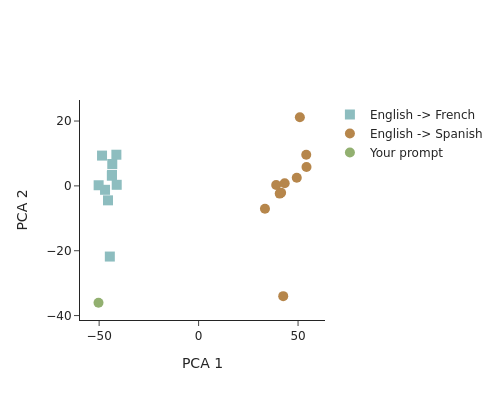

In [10]:
YOUR_PROMPT = "English: <YOUR_INPUT>, Espanol:"

with torch.no_grad():
  with model.trace(YOUR_PROMPT):
    # get activation at layer L & last token (:)
    activation = model.model.layers[LAYER].output[:, -1, :].save()

activation_low_dim = pca.transform(activation.cpu().float().numpy())

# your code here!
fig.add_trace(go.Scatter(
  x=activation_low_dim[:, 0],
  y=activation_low_dim[:, 1],
  mode='markers',
  marker=dict(symbol='circle', color="#92b070", size=10),
  name='Your prompt',
  hovertext=YOUR_PROMPT
))

What was the prompt you chose, and how did you come up with it?

> FILL IN YOUR ANSWER HERE

### Linear probing

In [11]:
import pandas as pd

languages_df = pd.DataFrame([
    {
        "en": "Hello.",
        "es": "Hola.",
        "fr": "Bonjour.",
        "de": "Hallo."
    },
    {
        "en": "Good night.",
        "es": "Buenas noches.",
        "fr": "Bonne nuit.",
        "de": "Gute Nacht."
    },
    {
        "en": "How are you?",
        "es": "¿Cómo estás?",
        "fr": "Comment ça va ?",
        "de": "Wie geht's?"
    },
    {
        "en": "I am happy.",
        "es": "Estoy feliz.",
        "fr": "Je suis heureux.",
        "de": "Ich bin glücklich."
    },
    {
        "en": "See you soon.",
        "es": "Hasta pronto.",
        "fr": "À bientôt.",
        "de": "Bis bald."
    },
    {
        "en": "Thank you.",
        "es": "Gracias.",
        "fr": "Merci.",
        "de": "Danke."
    },
    {
        "en": "Yes, please.",
        "es": "Sí, por favor.",
        "fr": "Oui, s'il vous plaît.",
        "de": "Ja, bitte."
    },
    {
        "en": "No, thanks.",
        "es": "No, gracias.",
        "fr": "Non, merci.",
        "de": "Nein, danke."
    },
    {
        "en": "I love you.",
        "es": "Te quiero.",
        "fr": "Je t'aime.",
        "de": "Ich liebe dich."
    },
    {
        "en": "It is cold.",
        "es": "Hace frío.",
        "fr": "Il fait froid.",
        "de": "Es ist kalt."
    }
])

In [12]:
import torch
from tqdm import trange

all_activations = []
with torch.no_grad():
  for i in trange(languages_df.shape[0]):
    row = languages_df.iloc[i]
    with model.trace(row.values.tolist()):
      all_activations.append(model.model.layers[LAYER].output[:, -1, :].save())

all_activations = torch.cat(all_activations, dim=0)

100%|██████████| 10/10 [00:30<00:00,  3.00s/it]


In [13]:
from sklearn.linear_model import RidgeClassifier

X = all_activations.cpu().float().numpy()
y = ['en', 'es', 'fr', 'de'] * len(languages_df)

linear_probe = RidgeClassifier(random_state=12)
linear_probe.fit(X, y)

linear_probe.score(X, y)

1.0

In [14]:
with torch.no_grad():
  with model.trace("Bon apetit"):
    activation = model.model.layers[LAYER].output[:, -1, :].save()

linear_probe.predict(activation.cpu().float().numpy())

array(['fr'], dtype='<U2')

### 🧠 Takeaways

In this section, we saw how models take in **token ids** as inputs and output a **probability distribution** over the next token in the sequence.

We also saw how little things like whitespace can throw off our model, because of how the text is tokenized! In the next section, we'll continue breaking down the model, this time looking into its internal computations.

Run this code when you're done with this section - we'll explore a different model in the next section.

In [15]:
del model # delete model to save memory, we won't need it for the next section!

## 2️⃣ Deep dive: deriving interventions from linear probes

As we just saw, even in a low-dimension space, we can decode the language of the input from the model's activation! But what's driving the difference between the activations of these different languages?

Different **linear probes** can give us directions in the latent space of the LLM that separate activations of different languages. But we should be careful, because **probes are likely to pick up on correlations instead of causal directions!**

To understand why this might happen, let's consider an example story.

![visualizing logistic regression vs. difference in means](https://github.com/AmirZur/nnsight-tutorials/blob/main/figures/steering%20visualization.gif?raw=true)

Imagine that Prof. X wants to improve the outcomes of his gifted students. Prof. X keeps track of how many assignments a student turned in and their average grade on those assignments, and wants to use this information to predict whether the student passed the final.

But **predicting** is not enough. Prof. X wants to use the information from his predictor to **improve** his students' performance on the final next year. Can his predictor give Prof. X useful information about the **intervention** he should design to improve student performance?

In [16]:
# create fake dataset of students
import numpy as np

np.random.seed(12)

N = 20

low_group_effort = np.random.normal(loc=5, scale=1.8, size=N)
high_group_effort = np.random.normal(loc=10, scale=1.8, size=N)

low_group_grade = 0.5 * low_group_effort + np.random.normal(loc=5, scale=0.3, size=N)
high_group_grade = 0.5 * high_group_effort + np.random.normal(loc=7, scale=0.3, size=N)

X = np.stack((
    np.concatenate((low_group_effort, high_group_effort)), # x-axis
    np.concatenate((low_group_grade, high_group_grade)) # y-axis
), axis=1)

X = X - X.mean(axis=0) # center

y = ['low'] * N + ['high'] * N

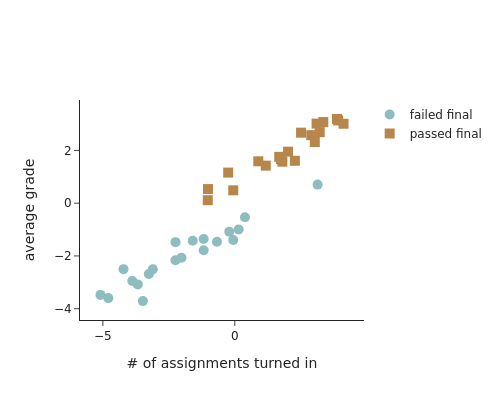

In [17]:
import plotly.graph_objects as go

fig = go.Figure()

mean_low = X[:N].mean(axis=0)
mean_high = X[N:].mean(axis=0)

fig.add_traces([
  go.Scatter(
    x=X[:N, 0],
    y=X[:N, 1],
    mode='markers',
    marker=dict(symbol='circle', color="#8dbdbf", size=10),
    name='failed final',
  ),
  go.Scatter(
    x=X[N:, 0],
    y=X[N:, 1],
    mode='markers',
    marker=dict(symbol='square', color="#b6864b", size=10),
    name='passed final',
  )
])

fig.update_layout(
  template='simple_white',
  width=500,
  height=400,
  xaxis_title='# of assignments turned in',
  yaxis_title='average grade',
  xaxis=dict(scaleanchor="y", scaleratio=1), # Anchor x-axis to y-axis with 1:1 ratio
  yaxis=dict(scaleanchor="x", scaleratio=1)  # Anchor y-axis to x-axis with 1:1 ratio
)

fig.show()

Looking at the data, we can see that the number of assignments turned in correlates with the average grade. Both average grade and number of assignments turned in also seem predictive of the students' performance on the final. Which feature will our probes pick out?

**Logistic regression probe (LR)**

Logistic regression will find the boundary that maximizes the margin between the students who passed and failed the final. However, it's **likely to pick up on spurious correlations that don't drive the difference between the two groups!**

In [18]:
from sklearn.linear_model import LogisticRegression

lr_probe = LogisticRegression(fit_intercept=False, random_state=12)
lr_probe.fit(X, y)

lr_probe.score(X, y)

0.975

In [19]:
theta = lr_probe.coef_[0]
theta

array([ 0.4126429 , -2.12310183])

Let's visualize the boundary drawn by our logistic regression probe. It neatly classifies between students who passed and students who failed the final!

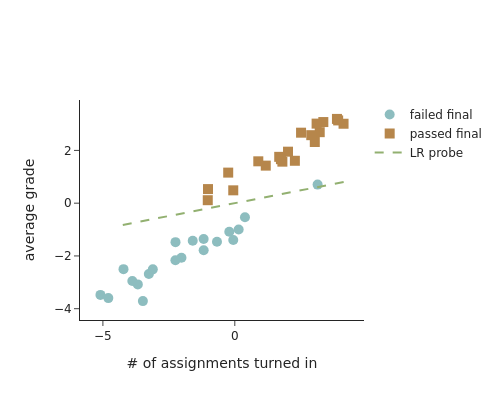

In [20]:
import plotly.graph_objects as go

# flip x & y -? flip around 45-degree line
# negate x -> flip around y-axis
theta_orthogonal = np.array([-theta[1], theta[0]])

# add trendline
t = np.linspace(-2, 2, 100)
probe_x = t * theta_orthogonal[0]
probe_y = t * theta_orthogonal[1]

fig.add_trace(
  go.Scatter(
    x=probe_x,
    y=probe_y,
    mode='lines',
    line=dict(color="#92b070", width=2, dash='dash'),
    name='LR probe'
  )
)

fig.show()

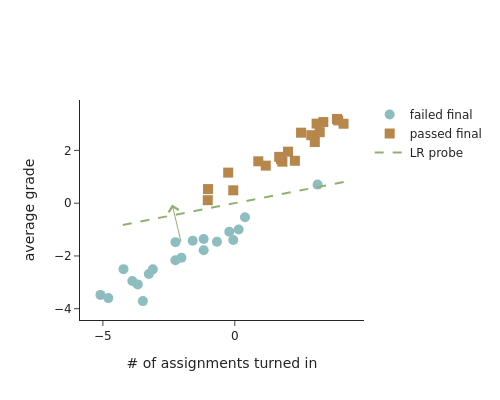

In [21]:
mean_low_transformed = mean_low - theta

fig.add_annotation(
  ax=mean_low[0],  # x-coordinate of the arrow's head
  ay=mean_low[1] + 0.2,  # y-coordinate of the arrow's head
  x=mean_low_transformed[0], # x-coordinate of the arrow's tail
  y=mean_low_transformed[1] - 0.2, # y-coordinate of the arrow's tail
  xref='x', yref='y', # Reference coordinates to the plot's x and y axes
  axref='x', ayref='y',
  showarrow=True,
  arrowhead=4, # Style of the arrowhead (e.g., 1, 2, 3, 4, 5)
  arrowsize=2,
  arrowwidth=1,
  arrowcolor="#92b070",
)

fig.show()

Presumably, bumping everyone's grades' up won't have the intended effect of helping people pass the final! Indeed, if we draw an arrow in the direction of the linear probe, we see that it doesn't do a great job at bringing the two distributions of students close together.

In this case, the **direction** of the LR probe isn't meaningful - it tells the students apart, but doesn't help us **steer** a student who's on track to fail the class towards passing it.

**Difference in means probe (aka. mean mass / MM)**

A simple but effective alternative to LR probes is **difference in means** (also known as **mean mass**) probing.

To classify between groups of students, we take the difference between the mean student who passed the final and the mean student who didn't pass. What we get is a direction vector that roughly tells the two classes apart, but more importantly tells us how to bridge between the two distribution.

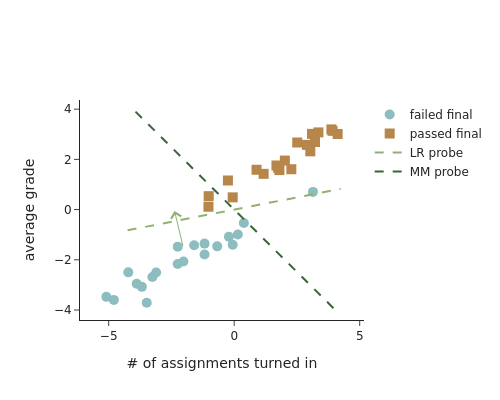

In [22]:
mean_mass_probe = mean_high - mean_low

mean_mass_probe_orthogonal = np.array([-mean_mass_probe[1], mean_mass_probe[0]])

# add trendline
t = np.linspace(-1, 1, 100)
probe_x = t * mean_mass_probe_orthogonal[0]
probe_y = t * mean_mass_probe_orthogonal[1]

fig.add_trace(
    go.Scatter(
        x=probe_x,
        y=probe_y,
        mode='lines',
        line=dict(color="#3a653a", width=2, dash='dash'),
        name='MM probe'
    )
)

fig.show()

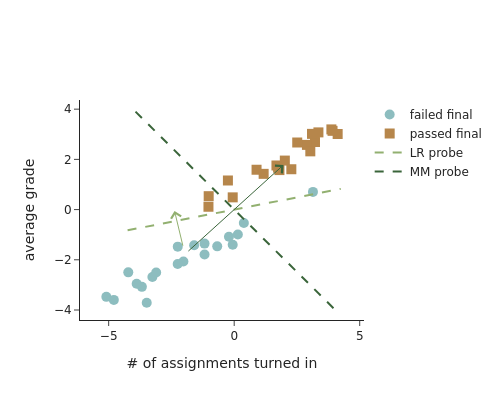

In [23]:
fig.add_annotation(
    ax=mean_low[0],  # x-coordinate of the arrow's head
    ay=mean_low[1] + 0.2,  # y-coordinate of the arrow's head
    x=mean_high[0], # x-coordinate of the arrow's tail
    y=mean_high[1] - 0.2, # y-coordinate of the arrow's tail
    xref='x', yref='y', # Reference coordinates to the plot's x and y axes
    axref='x', ayref='y',
    showarrow=True,
    arrowhead=4, # Style of the arrowhead (e.g., 1, 2, 3, 4, 5)
    arrowsize=2,
    arrowwidth=1,
    arrowcolor="#3a653a",
)

fig.show()

The mean mass probe suggests a better intervention - not only should students' grades go up, but they should also probably turn in more assignments in order to prepare for the final.

Even here, causality isn't guaranteed. For example, there might be other underlying causes behind why students couldn't turn in assignments. We are limited by the information in our dataset and the complexity of our intervention.

However, unlike with Prof. X who has to wait a whole year to try out ways to improve his students' final grades, we get to test our interventions on our LLMs right away! Let's see what it looks like to construct a "truth" steering vector on our LLM and use it to change a model's opinion about the truth of a sentence.

## 3️⃣ Controlling behavior by steering activations

### ✏ **Exercise 3**

**TODO**

*Hint: TODO*

What sentence did you use? Why do you think it has the similarity that it has?

> FILL IN YOUR ANSWER HERE